# Next Word Predictor — Week 5 Checkpoint

**Author:** Disha Janardhan

## Task Overview

This notebook implements the Week 5 milestone of the **Next Word Predictor** project. The goal is to predict the most likely word following a given context window of preceding words.

The task is framed as **multi-class classification**:
- **Input:** A sliding context window of `k` preceding words (k = 4 in this notebook)
- **Output:** The single most likely next word from a vocabulary of 10,000 words

### Pipeline
1. Download and clean 50 books from Project Gutenberg
2. Tokenize and explore the corpus
3. Build a truncated vocabulary (top 10,000 words)
4. Generate sliding-window (context, target) training pairs
5. Encode context windows as TF-IDF feature vectors
6. Train a Logistic Regression baseline classifier
7. Evaluate Top-1 and Top-3 accuracy on a held-out validation set

## Section 1 — Setup and Imports

In [ ]:
%pip install requests
%pip install numpy
%pip install matplotlib
%pip install pandas
%pip install scikit-learn
%pip install seaborn

In [3]:
import os
import re
import json
import time
import random
import pickle
import requests
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# --- Reproducibility ---
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# --- Hyperparameters (single source of truth) ---
CONTEXT_WINDOW = 4       # words used as input context
TOP_N_VOCAB    = 10_000  # vocabulary cap
MIN_WORD_FREQ  = 5       # discard words below this count
MAX_SAMPLES    = 500_000 # cap training samples

# --- Directory setup ---
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

print('Setup complete.')
print(f'  Context window : {CONTEXT_WINDOW} words')
print(f'  Vocabulary cap : {TOP_N_VOCAB:,} words')
print(f'  Max samples    : {MAX_SAMPLES:,}')

Setup complete.
  Context window : 4 words
  Vocabulary cap : 10,000 words
  Max samples    : 500,000


## Section 2 — Data Collection

We download 50 classic English-language books from [Project Gutenberg](https://www.gutenberg.org/). Books are cached locally so re-running the notebook does not re-download.

In [5]:
# 50 well-known Project Gutenberg book IDs
BOOK_IDS = [
    1342,  # Pride and Prejudice — Austen
    11,    # Alice's Adventures in Wonderland — Carroll
    84,    # Frankenstein — Shelley
    1661,  # The Adventures of Sherlock Holmes — Doyle
    2701,  # Moby Dick — Melville
    98,    # A Tale of Two Cities — Dickens
    1400,  # Great Expectations — Dickens
    46,    # A Christmas Carol — Dickens
    76,    # Adventures of Huckleberry Finn — Twain
    74,    # The Adventures of Tom Sawyer — Twain
    345,   # Dracula — Stoker
    1260,  # Jane Eyre — Brontë
    768,   # Wuthering Heights — Brontë
    2554,  # Crime and Punishment — Dostoevsky
    2600,  # War and Peace — Tolstoy
    1080,  # A Modest Proposal — Swift
    5200,  # The Metamorphosis — Kafka
    174,   # The Picture of Dorian Gray — Wilde
    244,   # A Study in Scarlet — Doyle
    1232,  # The Prince — Machiavelli
    2814,  # Dubliners — Joyce
    4300,  # Ulysses — Joyce
    16,    # Peter Pan — Barrie
    43,    # Dr Jekyll and Mr Hyde — Stevenson
    120,   # Treasure Island — Stevenson
    35,    # The Time Machine — Wells
    36,    # The War of the Worlds — Wells
    5230,  # The Invisible Man — Wells
    158,   # Emma — Austen
    161,   # Sense and Sensibility — Austen
    105,   # Persuasion — Austen
    730,   # Oliver Twist — Dickens
    3207,  # The Republic — Plato
    7370,  # Leviathan — Hobbes
    61,    # The Communist Manifesto — Marx
    2265,  # The Tempest — Shakespeare
    1514,  # Hamlet — Shakespeare
    1522,  # Macbeth — Shakespeare
    1513,  # Romeo and Juliet — Shakespeare
    2641,  # A Room with a View — Forster
    2148,  # The Brothers Karamazov — Dostoevsky
    600,   # Notes from the Underground — Dostoevsky
    1184,  # The Count of Monte Cristo — Dumas
    514,   # Little Women — Alcott
    1952,  # The Yellow Wallpaper — Gilman
    3825,  # Narrative of the Life of Frederick Douglass
    1251,  # Le Morte d'Arthur — Malory
    23,    # Narrative of Sojourner Truth
    2097,  # On the Origin of Species — Darwin
    3296,  # Relativity — Einstein
]

assert len(BOOK_IDS) == 50, f'Expected 50 book IDs, got {len(BOOK_IDS)}'
print(f'Book list ready: {len(BOOK_IDS)} books')

Book list ready: 50 books


In [6]:
def download_book(book_id, dest_dir='data/raw'):
    """Download a Gutenberg book by ID. Returns local path or None on failure."""
    path = os.path.join(dest_dir, f'{book_id}.txt')
    if os.path.exists(path) and os.path.getsize(path) > 1000:
        return path  # cache hit

    urls = [
        f'https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt',
        f'https://www.gutenberg.org/files/{book_id}/{book_id}-0.txt',
        f'https://www.gutenberg.org/files/{book_id}/{book_id}.txt',
    ]
    headers = {'User-Agent': 'Mozilla/5.0 (academic research project; Python/requests)'}

    for url in urls:
        try:
            resp = requests.get(url, headers=headers, timeout=30)
            if resp.status_code == 200 and len(resp.text) > 1000:
                with open(path, 'w', encoding='utf-8', errors='replace') as f:
                    f.write(resp.text)
                time.sleep(0.5)  # polite crawl delay
                return path
        except Exception:
            continue

    print(f'  FAILED: book {book_id}')
    return None


downloaded, failed = [], []
for i, bid in enumerate(BOOK_IDS):
    result = download_book(bid)
    if result:
        downloaded.append(bid)
        if (i + 1) % 10 == 0:
            print(f'  [{i+1}/50] {bid} ✓')
    else:
        failed.append(bid)

print(f'\nDownloaded: {len(downloaded)} books')
print(f'Failed    : {len(failed)} books')
if failed:
    print(f'Failed IDs: {failed}')

  [10/50] 74 ✓
  [20/50] 1232 ✓
  [30/50] 161 ✓
  [40/50] 2641 ✓
  [50/50] 3296 ✓

Downloaded: 50 books
Failed    : 0 books


## Section 3 — Text Cleaning

Each Project Gutenberg file contains a header and footer with licensing information, delimited by standardized markers:

```
*** START OF THE PROJECT GUTENBERG EBOOK <TITLE> ***
*** END OF THE PROJECT GUTENBERG EBOOK <TITLE> ***
```

We strip these sections, then lowercase all text and remove non-alphabetic characters.

In [7]:
START_RE = re.compile(r'\*{3}\s*START OF (?:THE |THIS )?PROJECT GUTENBERG.*?\*{3}', re.IGNORECASE)
END_RE   = re.compile(r'\*{3}\s*END OF (?:THE |THIS )?PROJECT GUTENBERG.*?\*{3}', re.IGNORECASE)


def strip_gutenberg_boilerplate(text):
    start_match = START_RE.search(text)
    end_match   = END_RE.search(text)
    if start_match and end_match:
        return text[start_match.end():end_match.start()]
    elif start_match:
        return text[start_match.end():]
    return text  # no markers found — return as-is


def clean_text(text):
    text = strip_gutenberg_boilerplate(text)
    text = text.lower()
    text = re.sub(r"[^a-z\s']", ' ', text)   # keep letters, spaces, apostrophes
    text = re.sub(r'\s+', ' ', text).strip()
    return text


cleaned_books = {}
all_text_parts = []
for bid in downloaded:
    raw = open(f'data/raw/{bid}.txt', encoding='utf-8', errors='replace').read()
    cleaned = clean_text(raw)
    cleaned_books[bid] = cleaned
    all_text_parts.append(cleaned)

full_corpus = ' '.join(all_text_parts)

print(f'Total characters after cleaning : {len(full_corpus):,}')
print(f'Preview (first 300 chars):')
print(full_corpus[:300])

Total characters after cleaning : 28,085,999
Preview (first 300 chars):
illustration george allen publisher charing cross road london ruskin house illustration reading jane s letters chap pride and prejudice by jane austen with a preface by george saintsbury and illustrations by hugh thomson illustration ruskin charing house cross road london george allen chiswick press


## Section 4 — Dataset Exploration and Visualization

In [8]:
# 4.1 — Tokenize and count word frequencies
tokens = full_corpus.split()  # simple whitespace tokenization — fast on large corpora
word_freq = Counter(tokens)

print(f'Total tokens          : {len(tokens):,}')
print(f'Unique words (raw)    : {len(word_freq):,}')
print(f'\nTop 10 most frequent words:')
for word, count in word_freq.most_common(10):
    print(f'  {word:<15} {count:>10,}')

Total tokens          : 5,382,110
Unique words (raw)    : 66,510

Top 10 most frequent words:
  the                278,503
  and                188,339
  of                 145,332
  to                 143,625
  a                  109,443
  i                  100,388
  in                  83,308
  that                73,854
  he                  73,794
  it                  67,395


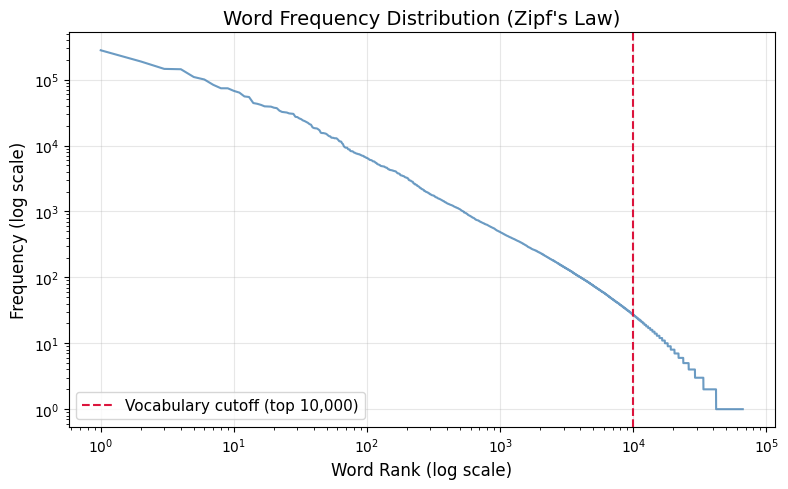

Figure 1 saved.


In [9]:
# 4.2 — Figure 1: Zipf's Law — word frequency vs rank (log-log scale)
freq_sorted = sorted(word_freq.values(), reverse=True)
ranks = list(range(1, len(freq_sorted) + 1))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(ranks, freq_sorted, linewidth=1.5, color='steelblue', alpha=0.8)
ax.axvline(x=TOP_N_VOCAB, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Vocabulary cutoff (top {TOP_N_VOCAB:,})')
ax.set_xlabel('Word Rank (log scale)', fontsize=12)
ax.set_ylabel('Frequency (log scale)', fontsize=12)
ax.set_title("Word Frequency Distribution (Zipf's Law)", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/zipf_distribution.png', dpi=150)
plt.show()
print('Figure 1 saved.')

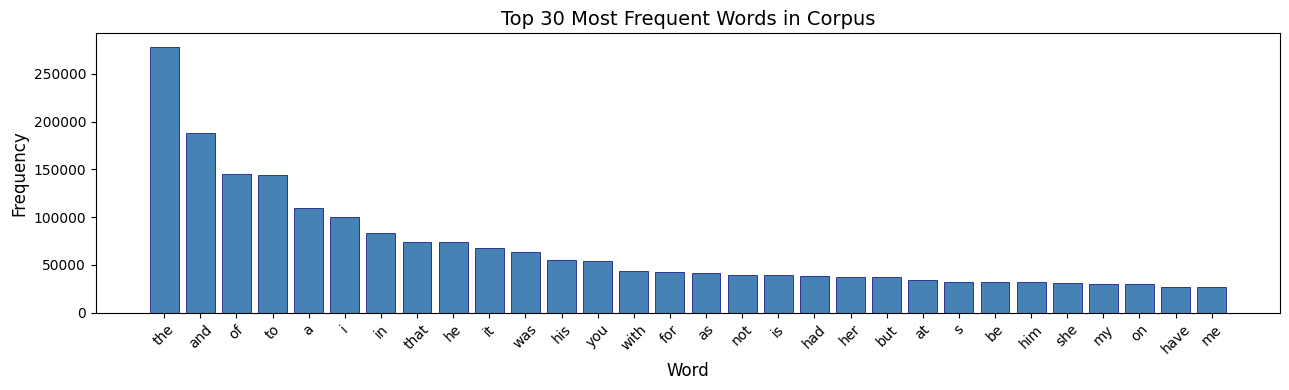

Figure 2 saved.


In [10]:
# 4.3 — Figure 2: Top 30 most common words
top30 = word_freq.most_common(30)
words_top30, counts_top30 = zip(*top30)

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(words_top30, counts_top30, color='steelblue', edgecolor='navy', linewidth=0.5)
ax.set_xlabel('Word', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Top 30 Most Frequent Words in Corpus', fontsize=14)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('outputs/figures/top30_words.png', dpi=150)
plt.show()
print('Figure 2 saved.')

In [11]:
# 4.4 — Per-book statistics table
book_stats = []
for bid in downloaded:
    toks = cleaned_books[bid].split()
    book_stats.append({
        'book_id': bid,
        'token_count': len(toks),
        'unique_words': len(set(toks)),
        'char_count': len(cleaned_books[bid]),
    })

df_books = pd.DataFrame(book_stats).sort_values('token_count', ascending=False)
print('Per-book statistics (top 10 by token count):')
print(df_books.head(10).to_string(index=False))
print(f'\nSummary statistics:')
print(df_books[['token_count', 'unique_words']].describe().round(0).to_string())

Per-book statistics (top 10 by token count):
 book_id  token_count  unique_words  char_count
    2600       583368         17445     3089615
    1184       469260         15757     2488752
    4300       268854         28990     1450865
    2701       219054         16956     1174222
    3207       212969          9607     1162327
    2554       209022          9406     1082979
     514       191238         10742      965585
    1260       189604         12541      977733
    1400       189051         10758      951726
    1251       169596          5637      854100

Summary statistics:
       token_count  unique_words
count         50.0          50.0
mean      107642.0        7264.0
std       109464.0        4782.0
min         3428.0        1085.0
25%        36560.0        4643.0
50%        72440.0        6204.0
75%       156197.0        9251.0
max       583368.0       28990.0


## Section 5 — Vocabulary Construction

We limit the vocabulary to the top 10,000 most frequent words that appear at least 5 times. This covers ~95% of all token occurrences (Zipf's law) while making the classification problem tractable.

Words outside this vocabulary are mapped to `<UNK>` in context windows, and samples where the **target** is `<UNK>` are dropped entirely. This keeps the context realistic while still avoiding impossible target labels.

In [12]:
# 5.1 — Build truncated vocabulary
vocab_filtered = {w: c for w, c in word_freq.items() if c >= MIN_WORD_FREQ}
top_n_words    = {w for w, _ in word_freq.most_common(TOP_N_VOCAB)}
final_vocab    = set(vocab_filtered) & top_n_words

# word → integer index; index 0 reserved for <UNK>
word2idx = {w: i + 1 for i, w in enumerate(sorted(final_vocab))}
word2idx['<UNK>'] = 0

print(f'Raw vocabulary size          : {len(word_freq):,}')
print(f'After min-frequency filter   : {len(vocab_filtered):,}')
print(f'After top-N cap              : {len(final_vocab):,}')
print(f'Final vocabulary (incl. UNK) : {len(word2idx):,}')

# Save vocabulary mapping
with open('data/processed/vocab.json', 'w') as f:
    json.dump(word2idx, f)
print('Vocabulary saved to data/processed/vocab.json')

Raw vocabulary size          : 66,510
After min-frequency filter   : 26,062
After top-N cap              : 10,000
Final vocabulary (incl. UNK) : 10,001
Vocabulary saved to data/processed/vocab.json


In [13]:
# 5.2 — Map tokens to vocab, keeping <UNK> inside context windows
def map_token(tok):
    return tok if tok in word2idx else '<UNK>'

mapped_tokens = [map_token(t) for t in tokens]

unk_count = mapped_tokens.count('<UNK>')
print(f'Total tokens                : {len(tokens):,}')
print(f'Mapped to <UNK>             : {unk_count:,} ({unk_count/len(tokens)*100:.1f}%)')
print(f'Tokens available for windows: {len(mapped_tokens):,}')

Total tokens                : 5,382,110
Mapped to <UNK>             : 250,612 (4.7%)
Tokens available for windows: 5,382,110


## Section 6 — Sliding Window Sample Generation

For each position in each book, we extract a context window of `CONTEXT_WINDOW` words and the immediately following word as the target label. Context windows are allowed to contain `<UNK>` so they still reflect the original text stream. We only drop a sample when the target word itself is `<UNK>`.

In [14]:
# 6.1 — Generate (context, target) pairs book by book
# Per-book cap so every book contributes proportionally. This keeps the dataset
# diverse and makes the book-level train/val split in Section 7 meaningful —
# a global cap would starve later books of samples.
WINDOW = CONTEXT_WINDOW
contexts, targets, sample_book_ids = [], [], []
per_book_cap = max(1, MAX_SAMPLES // len(downloaded))

for bid in downloaded:
    book_tokens = cleaned_books[bid].split()
    mapped_book_tokens = [map_token(tok) for tok in book_tokens]

    book_count = 0
    for i in range(len(mapped_book_tokens) - WINDOW):
        target_word = mapped_book_tokens[i + WINDOW]

        if target_word == '<UNK>':
            continue

        contexts.append(mapped_book_tokens[i : i + WINDOW])
        targets.append(target_word)
        sample_book_ids.append(bid)
        book_count += 1

        if book_count >= per_book_cap:
            break

print(f'Total samples generated : {len(contexts):,}')
print(f'Per-book cap            : {per_book_cap:,}')
print(f'Books contributing      : {len(set(sample_book_ids)):,}')
print(f'Example context/target  : {contexts[0]} → "{targets[0]}"')

Total samples generated : 489,218
Per-book cap            : 10,000
Books contributing      : 50
Example context/target  : ['george', 'allen', '<UNK>', '<UNK>'] → "cross"


In [15]:
# 6.2 — Save samples to CSV
df_samples = pd.DataFrame(
    {f'w{i}': [c[i] for c in contexts] for i in range(WINDOW)}
)
df_samples['target'] = targets
df_samples['book_id'] = sample_book_ids
df_samples.to_csv('data/processed/samples.csv', index=False)

print(f'Samples saved to data/processed/samples.csv')
print(f'Shape: {df_samples.shape}')
print(df_samples.head(5))

Samples saved to data/processed/samples.csv
Shape: (489218, 6)
       w0      w1      w2     w3        target  book_id
0  george   allen   <UNK>  <UNK>         cross     1342
1   allen   <UNK>   <UNK>  cross          road     1342
2   <UNK>   <UNK>   cross   road        london     1342
3   cross    road  london  <UNK>         house     1342
4    road  london   <UNK>  house  illustration     1342


## Section 7 — Feature Engineering: TF-IDF on Context Windows

Each context window (e.g., `["the", "quick", "brown", "fox"]`) is concatenated into a single string and treated as a short "document". TF-IDF is then applied over a fixed vocabulary of 10,000 words.

To avoid leakage, we split the data by book before training. This means no book contributes samples to both the training and validation sets.

**Why TF-IDF over simple one-hot?**  
TF-IDF downweights very common words like "the" and "and" (low IDF) that appear in nearly every context window and carry little discriminative signal. Rarer, more semantically specific words receive higher weight and thus have more influence on the prediction.

In [16]:
# 7.1 — Book-level train/validation split, then fit TF-IDF on training data only
context_docs = [' '.join(row) for row in contexts]

le = LabelEncoder()
y_all = le.fit_transform(targets)

n_val_books = max(1, round(0.15 * len(downloaded)))
validation_books = set(random.sample(downloaded, n_val_books))

train_idx = [i for i, bid in enumerate(sample_book_ids) if bid not in validation_books]
val_idx   = [i for i, bid in enumerate(sample_book_ids) if bid in validation_books]

X_train_docs = [context_docs[i] for i in train_idx]
X_val_docs   = [context_docs[i] for i in val_idx]
y_train      = y_all[train_idx]
y_val        = y_all[val_idx]

tfidf = TfidfVectorizer(
    vocabulary=list(word2idx.keys()),  # fixed vocab — no data leakage, stable feature space
    sublinear_tf=True,                 # log(1 + tf) dampening
    ngram_range=(1, 1),
)
tfidf.fit(X_train_docs)

X_train = tfidf.transform(X_train_docs)  # stays sparse — do NOT call .toarray()
X_val   = tfidf.transform(X_val_docs)

print(f'Validation books : {sorted(validation_books)}')
print(f'Training set     : {X_train.shape[0]:,} samples × {X_train.shape[1]:,} features')
print(f'Validation set   : {X_val.shape[0]:,} samples × {X_val.shape[1]:,} features')
print(f'Unique target classes : {len(le.classes_):,}')
print(f'Matrix type      : {type(X_train).__name__} (sparse)')

Validation books : [11, 46, 76, 174, 1080, 1400, 2148, 2600]
Training set     : 416,025 samples × 10,001 features
Validation set   : 73,193 samples × 10,001 features
Unique target classes : 9,406
Matrix type      : csr_matrix (sparse)


Feature matrix density: 0.0356%
(expected ~4/10001 = 0.0400% since each window has 4 words)


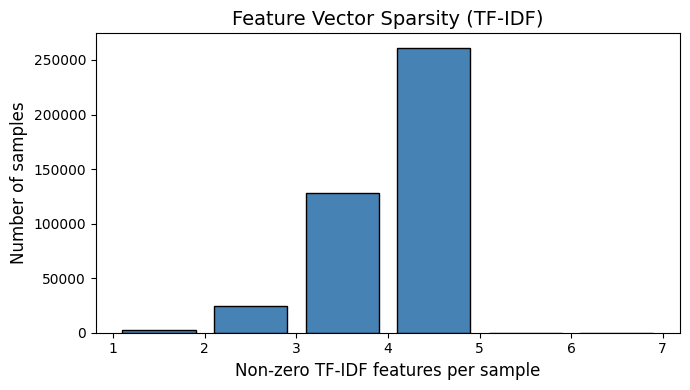

Figure 4 saved.


In [17]:
# 7.2 — Figure 4: TF-IDF feature sparsity
density = X_train.nnz / (X_train.shape[0] * X_train.shape[1])
print(f'Feature matrix density: {density:.4%}')
print(f'(expected ~{WINDOW}/{len(word2idx)} = {WINDOW/len(word2idx):.4%} since each window has {WINDOW} words)')

nnz_per_sample = np.diff(X_train.indptr)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(nnz_per_sample, bins=range(1, WINDOW + 4), edgecolor='black',
        color='steelblue', rwidth=0.8)
ax.set_xlabel('Non-zero TF-IDF features per sample', fontsize=12)
ax.set_ylabel('Number of samples', fontsize=12)
ax.set_title('Feature Vector Sparsity (TF-IDF)', fontsize=14)
ax.set_xticks(range(1, WINDOW + 4))
plt.tight_layout()
plt.savefig('outputs/figures/tfidf_sparsity.png', dpi=150)
plt.show()
print('Figure 4 saved.')

## Section 8 — Baseline Model: SGD Logistic Regression

`SGDClassifier(loss='log_loss')` is mathematically equivalent to Logistic Regression but trained with stochastic gradient descent. It is used here instead of `LogisticRegression(solver='saga')` because `saga` builds a gradient memory table of size `n_samples × n_classes` — with 500k samples and 10k classes that would require ~40 GB of RAM. SGDClassifier only stores the weight matrix (`n_classes × n_features` ≈ 400 MB) and computes mini-batch gradients on-the-fly.

### Optional — Download Pre-trained Model Instead of Training

Training the model can take several minutes. If you want to skip training, run the optional cell below to download the saved model bundle that I uploaded after training on my laptop, from Hugging Face and load it directly. Run either this optional cell or the training cell below, not both.

In [18]:
# Optional: download and load the pre-trained model bundle from Hugging Face
import os
import pickle
import urllib.request

MODEL_URL = 'https://huggingface.co/disha1609/next-word-predictor/resolve/main/model_logistic.pkl'
MODEL_PATH = 'outputs/model_logistic.pkl'

os.makedirs('outputs', exist_ok=True)

if not os.path.exists(MODEL_PATH):
    print('Downloading pre-trained model from Hugging Face...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print('Download complete.')
else:
    print('Model already exists locally.')

with open(MODEL_PATH, 'rb') as f:
    model_bundle = pickle.load(f)

lr = model_bundle['model']
tfidf = model_bundle['tfidf']
le = model_bundle['label_encoder']
word2idx = model_bundle['word2idx']

print('Pre-trained model loaded successfully.')

Model already exists locally.
Pre-trained model loaded successfully.


### Optional — Train SGD Logistic Regression

In [ ]:
# 8.1 — Train SGD Logistic Regression
print('Training SGD Logistic Regression...')

lr = SGDClassifier(
    loss='log_loss',      # log loss = logistic regression
    penalty='l2',
    alpha=1e-4,           # regularisation (equiv. to C=10000 in LR)
    max_iter=20,
    tol=1e-3,
    n_iter_no_change=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=0,
)
lr.fit(X_train, y_train)
print('Training complete.')

In [19]:
# 8.2 — Evaluate: Top-1, Top-3, Top-5 accuracy
# decision_function columns correspond to lr.classes_ (not necessarily 0..n-1 in order).
# argpartition gives column indices — must map through lr.classes_ to get true class values.
y_pred_lr = lr.predict(X_val)
acc_top1_lr = accuracy_score(y_val, y_pred_lr)

BATCH = 2_000
top3_hits, top5_hits = 0, 0
for start in range(0, len(y_val), BATCH):
    sl = slice(start, start + BATCH)
    scores = lr.decision_function(X_val[sl])              # (batch, len(lr.classes_))
    top5_cols = np.argpartition(scores, -5, axis=1)[:, -5:]
    top3_cols = np.argpartition(scores, -3, axis=1)[:, -3:]
    # Map column indices → actual class values
    top5_classes = lr.classes_[top5_cols]                 # (batch, 5)
    top3_classes = lr.classes_[top3_cols]                 # (batch, 3)
    yb = y_val[sl]
    top3_hits += int(np.any(top3_classes == yb[:, None], axis=1).sum())
    top5_hits += int(np.any(top5_classes == yb[:, None], axis=1).sum())

acc_top3_lr = top3_hits / len(y_val)
acc_top5_lr = top5_hits / len(y_val)

print(f'SGD Logistic Regression — Validation Results:')
print(f'  Top-1 Accuracy : {acc_top1_lr:.4f}  ({acc_top1_lr*100:.2f}%)')
print(f'  Top-3 Accuracy : {acc_top3_lr:.4f}  ({acc_top3_lr*100:.2f}%)')
print(f'  Top-5 Accuracy : {acc_top5_lr:.4f}  ({acc_top5_lr*100:.2f}%)')

SGD Logistic Regression — Validation Results:
  Top-1 Accuracy : 0.0691  (6.91%)
  Top-3 Accuracy : 0.1509  (15.09%)
  Top-5 Accuracy : 0.1956  (19.56%)


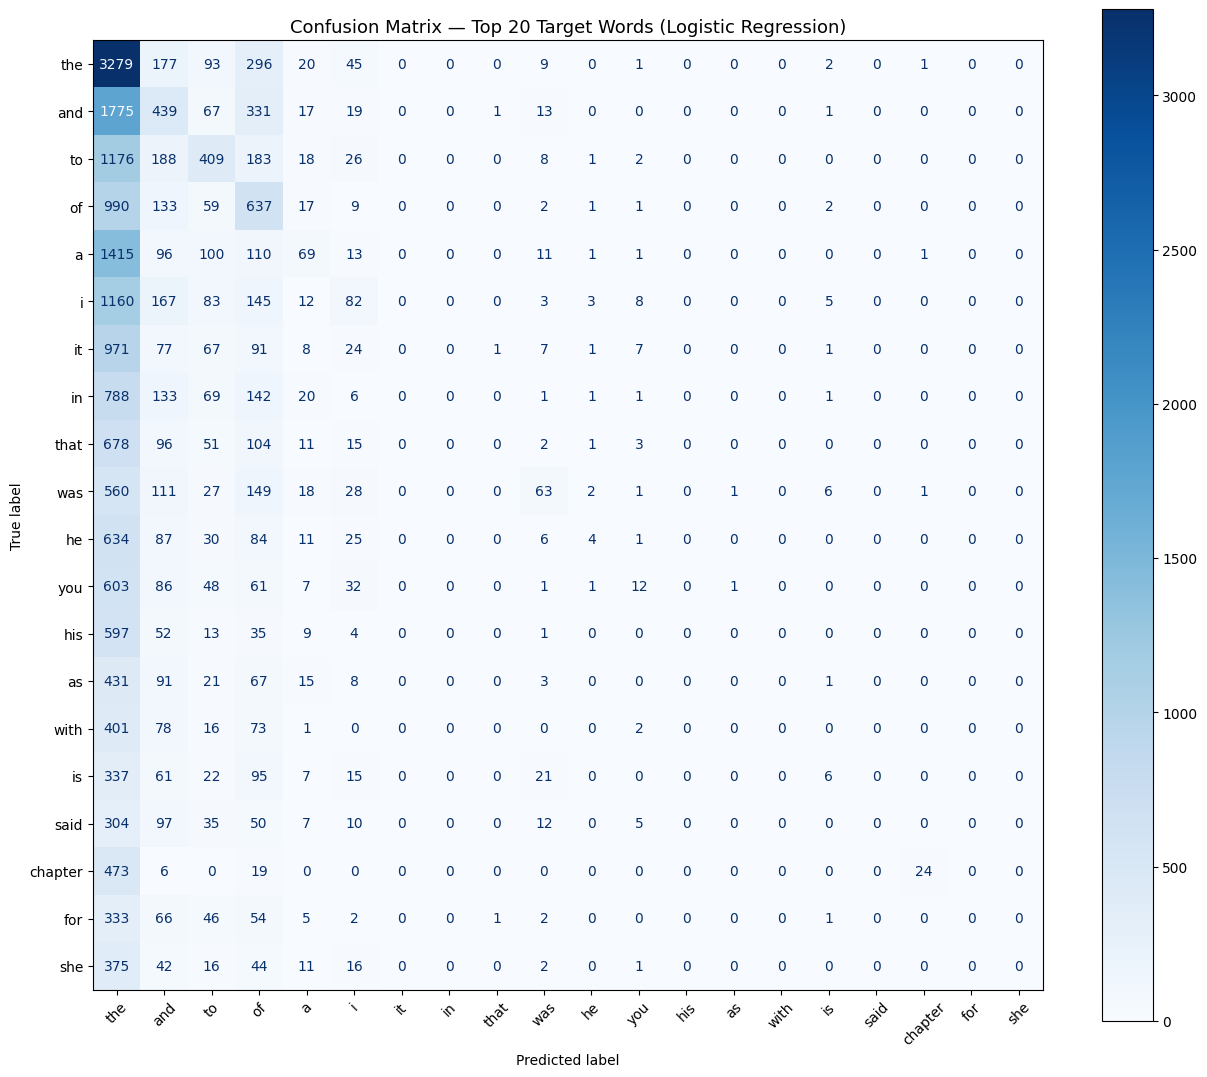

Figure 5 saved.


In [20]:
# 8.3 — Figure 5: Confusion matrix for top-20 most frequent target words
top20_indices = [idx for idx, _ in Counter(y_val.tolist()).most_common(20)]
top20_classes = [le.classes_[i] for i in top20_indices]

mask = np.isin(y_val, top20_indices)
cm = confusion_matrix(y_val[mask], y_pred_lr[mask], labels=top20_indices)

fig, ax = plt.subplots(figsize=(13, 11))
disp = ConfusionMatrixDisplay(cm, display_labels=top20_classes)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — Top 20 Target Words (Logistic Regression)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/figures/confusion_matrix_lr.png', dpi=150)
plt.show()
print('Figure 5 saved.')

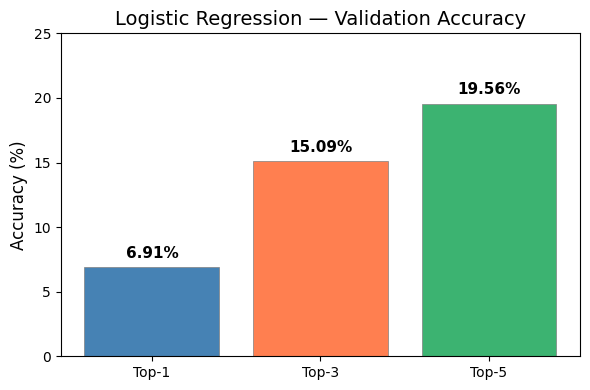

Figure 6 saved.


In [21]:
# 8.4 — Figure 6: Accuracy summary bar chart
fig, ax = plt.subplots(figsize=(6, 4))
labels  = ['Top-1', 'Top-3', 'Top-5']
values  = [acc_top1_lr * 100, acc_top3_lr * 100, acc_top5_lr * 100]
colors  = ['steelblue', 'coral', 'mediumseagreen']

bars = ax.bar(labels, values, color=colors, edgecolor='grey', linewidth=0.5)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Logistic Regression — Validation Accuracy', fontsize=14)
ax.set_ylim(0, max(25, max(values) * 1.15))
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{v:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('outputs/figures/accuracy_summary.png', dpi=150)
plt.show()
print('Figure 6 saved.')

In [22]:
# 8.5 — Save model bundle
model_bundle = {'model': lr, 'tfidf': tfidf, 'label_encoder': le, 'word2idx': word2idx}
with open('outputs/model_logistic.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)
print('Model bundle saved to outputs/model_logistic.pkl')

Model bundle saved to outputs/model_logistic.pkl


## Section 9 — Quick Inference Demo

This gives a clearer picture of what the model is actually learning.

In [26]:
def predict_next_word(prompt, model, tfidf_vec, label_enc, word_to_idx, top_k=5):
    """Predict the top-k most likely next words given a text prompt."""
    words = re.sub(r"[^a-z\s']", ' ', prompt.lower()).split()
    words = [w if w in word_to_idx else '<UNK>' for w in words]
    context = words[-CONTEXT_WINDOW:]

    if len(context) < CONTEXT_WINDOW:
        context = ['the'] * (CONTEXT_WINDOW - len(context)) + context

    doc = ' '.join(context)
    X = tfidf_vec.transform([doc])
    scores = model.decision_function(X)[0]                # (n_model_classes,)
    top_cols = np.argpartition(scores, -top_k)[-top_k:]
    top_cols = top_cols[np.argsort(scores[top_cols])[::-1]]
    top_classes = model.classes_[top_cols]                # map col → class value
    top_words = label_enc.classes_[top_classes]           # map class value → word string

    print(f'Prompt  : "{prompt}"')
    print(f'Context : {context}')
    print(f'Top-{top_k} predictions:')
    for rank, word in enumerate(top_words, 1):
        print(f'  {rank}. "{word}"')


predict_next_word('it was the best of', lr, tfidf, le, word2idx)
print()
predict_next_word('to be or not to', lr, tfidf, le, word2idx)
print()
predict_next_word('she opened the door', lr, tfidf, le, word2idx)
print()

Prompt  : "it was the best of"
Context : ['was', 'the', 'best', 'of']
Top-5 predictions:
  1. "the"
  2. "of"
  3. "and"
  4. "a"
  5. "in"

Prompt  : "to be or not to"
Context : ['be', 'or', 'not', 'to']
Top-5 predictions:
  1. "the"
  2. "to"
  3. "a"
  4. "in"
  5. "of"

Prompt  : "she opened the door"
Context : ['she', 'opened', 'the', 'door']
Top-5 predictions:
  1. "and"
  2. "the"
  3. "of"
  4. "was"
  5. "to"



## Section 10 — Results Summary

### Key Dataset Characteristics

In [24]:
print('=' * 55)
print('DATASET CHARACTERISTICS')
print('=' * 55)
print(f'  Books successfully downloaded : {len(downloaded)}')
print(f'  Total tokens in corpus        : {len(tokens):,}')
print(f'  Raw vocabulary size           : {len(word_freq):,}')
print(f'  Truncated vocabulary size     : {len(final_vocab):,}')
print(f'  Context window length         : {CONTEXT_WINDOW} words')
print(f'  Total training samples        : {X_train.shape[0]:,}')
print(f'  Total validation samples      : {X_val.shape[0]:,}')
print(f'  Feature dimensions (TF-IDF)   : {X_train.shape[1]:,}')
print()
print('=' * 55)
print('MODEL RESULTS — LOGISTIC REGRESSION')
print('=' * 55)
print(f'  Top-1 Accuracy  : {acc_top1_lr*100:.2f}%')
print(f'  Top-3 Accuracy  : {acc_top3_lr*100:.2f}%')
print(f'  Top-5 Accuracy  : {acc_top5_lr*100:.2f}%')
print(f'  Random baseline : {1/len(le.classes_)*100:.4f}%')
print('=' * 55)

DATASET CHARACTERISTICS
  Books successfully downloaded : 50
  Total tokens in corpus        : 5,382,110
  Raw vocabulary size           : 66,510
  Truncated vocabulary size     : 10,000
  Context window length         : 4 words
  Total training samples        : 416,025
  Total validation samples      : 73,193
  Feature dimensions (TF-IDF)   : 10,001

MODEL RESULTS — LOGISTIC REGRESSION
  Top-1 Accuracy  : 6.91%
  Top-3 Accuracy  : 15.09%
  Top-5 Accuracy  : 19.56%
  Random baseline : 0.0106%
